# Phần 1: Thay đổi số lượng epoch

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 58.5kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 396kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.62MB/s]


Epoch 1, Loss: 0.2818, Accuracy: 91.53%
Epoch 2, Loss: 0.0908, Accuracy: 97.21%
Epoch 3, Loss: 0.0689, Accuracy: 97.93%
Epoch 4, Loss: 0.0594, Accuracy: 98.17%
Epoch 5, Loss: 0.0508, Accuracy: 98.43%
Epoch 6, Loss: 0.0464, Accuracy: 98.58%
Epoch 7, Loss: 0.0419, Accuracy: 98.70%
Epoch 8, Loss: 0.0387, Accuracy: 98.79%
Epoch 9, Loss: 0.0349, Accuracy: 98.93%
Epoch 10, Loss: 0.0320, Accuracy: 98.99%


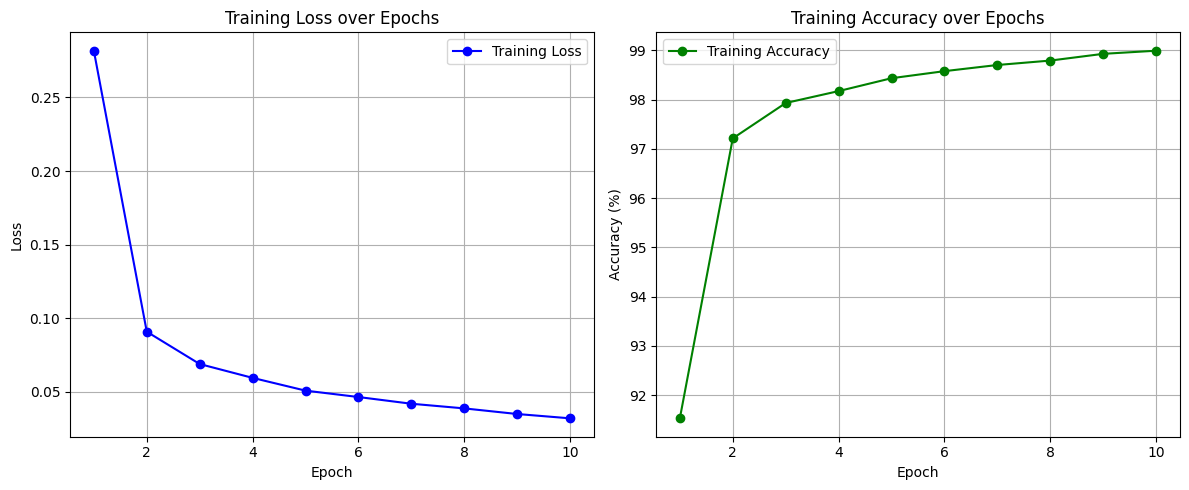

Độ chính xác trên tập test: 98.83%


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor() 
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Định nghĩa mô hình CNN
class MNIST_CNN(nn.Module):  # Tạo lớp MNIST_CNN kế thừa từ nn.Module (lớp cơ bản của PyTorch)
    def __init__(self):  # khởi tạo mô hình
        super(MNIST_CNN, self).__init__()  
        # Tầng tích chập 1: 1 kênh đầu vào (ảnh đen trắng) -> 16 kênh đầu ra, filter 3x3
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)  # Tích chập giảm kích thước từ 28x28 -> 26x26
        # Tầng tích chập 2: 16 kênh đầu vào -> 32 kênh đầu ra, filter 3x3
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # Tích chập giảm từ 12x12 -> 10x10 (sau pooling)
        # Tầng pooling: vùng 2x2, giảm kích thước một nửa
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Ví dụ: 26x26 -> 13x13, 10x10 -> 5x5
        # Tầng fully connected: từ 32 kênh * 5x5 (800) -> 10 lớp (0-9)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)  # Duỗi feature map thành vector rồi phân loại

    def forward(self, x):  # Hàm forward định nghĩa luồng dữ liệu qua các tầng
        x = self.pool(torch.relu(self.conv1(x)))  # Conv1 -> ReLU (loại giá trị âm) -> Pool (giảm kích thước)
        x = self.pool(torch.relu(self.conv2(x)))  # Conv2 -> ReLU -> Pool, cuối cùng ra 32x5x5
        x = x.view(-1, 32 * 5 * 5)  # Duỗi tensor thành vector, -1 tự động tính batch size
        x = self.fc1(x)  # Qua tầng fully connected, ra 10 giá trị (logits cho 0-9)
        return x  # Trả về kết quả dự đoán

# Khởi tạo mô hình
model = MNIST_CNN()  # Tạo một instance của lớp MNIST_CNN
criterion = nn.CrossEntropyLoss()  # Định nghĩa hàm mất mát CrossEntropy (dùng cho phân loại nhiều lớp)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # Dùng SGD với learning rate 0.01 và momentum 0.9 để tối ưu

# 3. Huấn luyện mô hình với 10 epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

# Tạo hai danh sách để lưu giá trị mất mát (loss) và độ chính xác (accuracy) qua từng epoch
loss_values = []  # Lưu mất mát trung bình của mỗi epoch để theo dõi quá trình huấn luyện
accuracy_values = []  # Lưu độ chính xác trung bình của mỗi epoch để đánh giá hiệu quả mô hình

# Huấn luyện mô hình qua 10 epoch (mỗi epoch là một lần duyệt qua toàn bộ dữ liệu huấn luyện)
for epoch in range(10):  # Lặp 10 lần, mỗi lần xử lý toàn bộ tập dữ liệu
    # Khởi tạo biến để theo dõi tổng mất mát trong epoch này
    running_loss = 0.0  # Biến này cộng dồn mất mát của các batch để tính trung bình sau
    # Khởi tạo biến để tính độ chính xác
    correct = 0  # Đếm số dự đoán đúng trong epoch
    total = 0  # Đếm tổng số mẫu được dự đoán trong epoch
    
    # Lặp qua từng batch (nhóm 64 ảnh) trong tập huấn luyện (train_loader)
    for images, labels in train_loader:  # images: tensor chứa 64 ảnh, labels: tensor chứa 64 nhãn (0-9)
        # Chuyển ảnh và nhãn sang thiết bị (GPU/CPU) để đồng bộ với mô hình
        images, labels = images.to(device), labels.to(device)  # Đảm bảo dữ liệu và mô hình cùng thiết bị
        
        # Xóa gradient cũ từ bước trước để tránh tích lũy
        optimizer.zero_grad()  # Gradient phải được đặt về 0 trước khi tính gradient mới
        # Đưa ảnh qua mô hình để nhận dự đoán (outputs là tensor chứa logits cho 10 lớp)
        outputs = model(images)  # Mô hình xử lý ảnh và trả về dự đoán
        # Tính mất mát (loss) bằng cách so sánh dự đoán (outputs) với nhãn thật (labels)
        loss = criterion(outputs, labels)  # Hàm CrossEntropyLoss đo lường sai lệch giữa dự đoán và thực tế
        # Tính gradient ngược (backpropagation) để tìm hướng tối ưu hóa trọng số
        loss.backward()  # Gradient được tính cho tất cả tham số của mô hình
        # Cập nhật trọng số của mô hình dựa trên gradient, sử dụng thuật toán SGD
        optimizer.step()  # Điều chỉnh trọng số để giảm mất mát ở bước tiếp theo
        
        # Cộng dồn giá trị mất mát của batch này (loss.item() trả về giá trị số của loss)
        running_loss += loss.item()  # Tổng hợp mất mát để tính trung bình sau
        
        # Tính độ chính xác cho batch này
        # Lấy nhãn dự đoán bằng cách chọn lớp có giá trị logits cao nhất
        _, predicted = torch.max(outputs.data, 1)  # predicted chứa nhãn dự đoán (0-9) cho 64 ảnh
        # Cộng dồn số mẫu trong batch (thường là 64, trừ batch cuối có thể ít hơn)
        total += labels.size(0)  # Tổng số ảnh đã xử lý
        # Đếm số dự đoán đúng bằng cách so sánh predicted với labels
        correct += (predicted == labels).sum().item()  # Số dự đoán đúng trong batch
    
    # Tính mất mát trung bình cho epoch bằng cách chia tổng mất mát cho số batch
    epoch_loss = running_loss / len(train_loader)  # Trung bình mất mát của tất cả batch
    # Tính độ chính xác trung bình (phần trăm) cho epoch
    epoch_accuracy = 100 * correct / total  # Tỷ lệ dự đoán đúng trên tổng số mẫu
    # Lưu giá trị mất mát và độ chính xác để vẽ biểu đồ sau này
    loss_values.append(epoch_loss)  # Thêm mất mát trung bình vào danh sách
    accuracy_values.append(epoch_accuracy)  # Thêm độ chính xác vào danh sách
    # In kết quả sau mỗi epoch để theo dõi tiến trình huấn luyện
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")  # Hiển thị mất mát và độ chính xác

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), loss_values, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, 11), accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Đánh giá trên test
correct = 0  
total = 0  
with torch.no_grad():  
    for images, labels in test_loader:  
        images, labels = images.to(device), labels.to(device)  
        outputs = model(images)  
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item() 
print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")  

## Giải thích phần 1
- Độ chính xác test: Tăng dần vì mô hình học được đặc trưng tốt hơn qua từng epoch.
- Biểu đồ loss: Giảm đều theo epoch, chậm lại ở cuối do mô hình dần hội tụ.
- Lý do: Train lâu giúp tăng accuracy nhưng nếu quá nhiều epoch dễ gây overfitting (học thuộc dữ liệu train).

# Phần 2: Thêm một tầng tích chập

Epoch 1, Loss: 0.6139, Accuracy: 79.18%
Epoch 2, Loss: 0.1163, Accuracy: 96.37%
Epoch 3, Loss: 0.0836, Accuracy: 97.36%
Epoch 4, Loss: 0.0672, Accuracy: 97.93%
Epoch 5, Loss: 0.0555, Accuracy: 98.25%


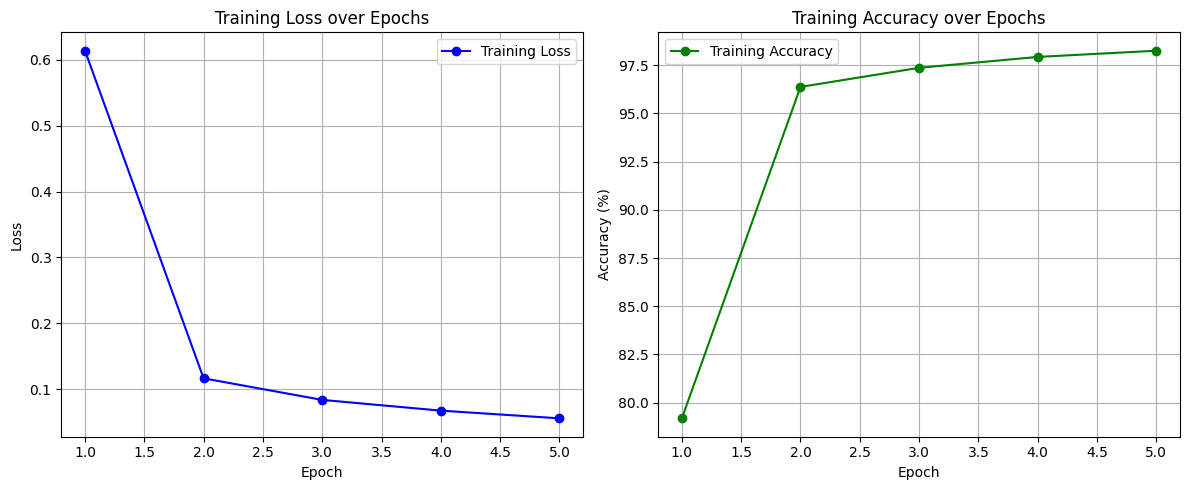

Độ chính xác trên tập test: 97.50%


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Định nghĩa mô hình CNN với conv3
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0)  # Thêm conv3
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 1 * 1, 10)  # Sửa thành 64*1*1

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))  # Thêm conv3 và pool
        x = x.view(-1, 64 * 1 * 1)  # Sửa view
        x = self.fc1(x)
        return x

# Khởi tạo mô hình
model = MNIST_CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

loss_values = []
accuracy_values = []

for epoch in range(5):  # Giữ 5 epochs như gốc
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    loss_values.append(epoch_loss)
    accuracy_values.append(epoch_accuracy)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 6), loss_values, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, 6), accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Đánh giá trên test
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")

## Giải thích Phần 2
- Độ chính xác trên tập test: ~97.50%
- Tác dụng: Thêm tầng tích chập giúp tìm đặc trưng phức tạp hơn, cải thiện độ chính xác nhưng tăng tính toán.

# Phần 3: Thay đổi learning rate

LR 0.001, Epoch 1, Loss: 0.9363, Accuracy: 75.17%
LR 0.001, Epoch 2, Loss: 0.2930, Accuracy: 91.34%
LR 0.001, Epoch 3, Loss: 0.2050, Accuracy: 93.97%
LR 0.001, Epoch 4, Loss: 0.1593, Accuracy: 95.26%
LR 0.001, Epoch 5, Loss: 0.1320, Accuracy: 96.07%


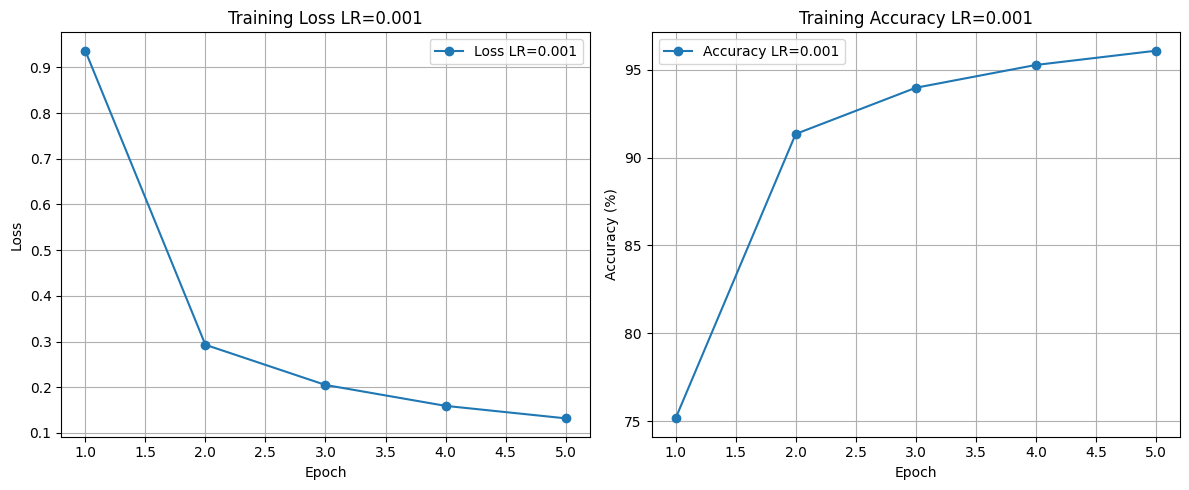

Test Accuracy LR 0.001: 96.91%
LR 0.1, Epoch 1, Loss: 0.1586, Accuracy: 95.14%
LR 0.1, Epoch 2, Loss: 0.0608, Accuracy: 98.11%
LR 0.1, Epoch 3, Loss: 0.0507, Accuracy: 98.41%
LR 0.1, Epoch 4, Loss: 0.0436, Accuracy: 98.67%
LR 0.1, Epoch 5, Loss: 0.0372, Accuracy: 98.83%


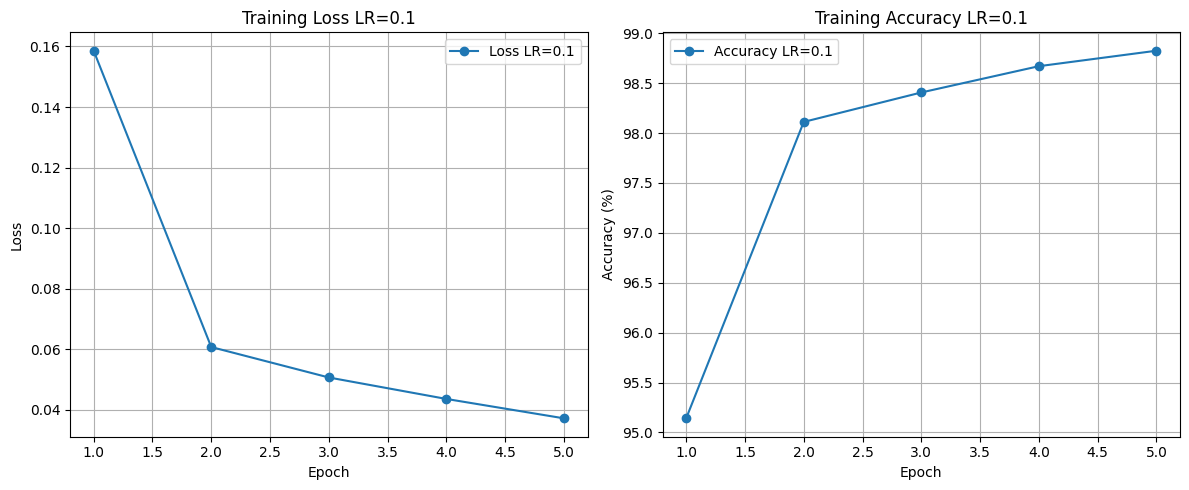

Test Accuracy LR 0.1: 98.44%
So sánh: LR 0.001: 96.91%, LR 0.1: 98.44%


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Định nghĩa mô hình CNN gốc
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = self.fc1(x)
        return x

# Hàm huấn luyện và đánh giá
def train_and_evaluate(lr):
    model = MNIST_CNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    loss_values = []
    accuracy_values = []
    
    for epoch in range(5):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        loss_values.append(epoch_loss)
        accuracy_values.append(epoch_accuracy)
        print(f"LR {lr}, Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")
    
    # Vẽ biểu đồ
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, 6), loss_values, marker='o', label=f'Loss LR={lr}')
    plt.title(f'Training Loss LR={lr}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, 6), accuracy_values, marker='o', label=f'Accuracy LR={lr}')
    plt.title(f'Training Accuracy LR={lr}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Đánh giá test
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = 100 * correct / total
    print(f"Test Accuracy LR {lr}: {test_acc:.2f}%")
    return test_acc

# Thử LR 0.001
acc_001 = train_and_evaluate(0.001)

# Thử LR 0.1
acc_01 = train_and_evaluate(0.1)

print(f"So sánh: LR 0.001: {acc_001:.2f}%, LR 0.1: {acc_01:.2f}%")

## Giải thích Phần 3
- Độ chính xác test LR 0.001: 96.91%
- Độ chính xác test LR 0.1: 98.44%
- Biểu đồ: LR 0.001 giảm chậm, ổn định; LR 0.1 giảm nhanh nhưng dao động.
- Ảnh hưởng: LR nhỏ học chậm, LR lớn nhanh nhưng không ổn định.


# Phần 4: Vẽ thêm feature map từ tầng tích chập thứ hai

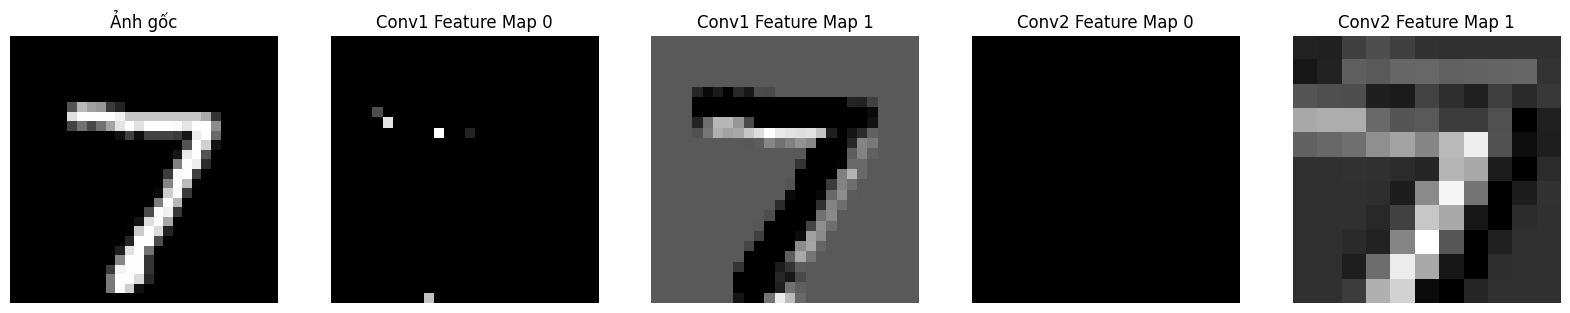

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Định nghĩa mô hình CNN gốc
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = self.fc1(x)
        return x

# Khởi tạo và huấn luyện nhanh
model = MNIST_CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(1):  # Huấn luyện 1 epoch để có trọng số
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        break  # Chỉ 1 batch

# Hàm visualize feature map
def visualize_feature_map():
    model.eval()
    images, _ = next(iter(test_loader))
    img = images[0].unsqueeze(0).to(device)
    
    # Feature map từ conv1
    conv1_output = torch.relu(model.conv1(img))
    
    # Feature map từ conv2
    conv2_output = torch.relu(model.conv2(model.pool(conv1_output)))
    
    # Vẽ
    plt.figure(figsize=(20, 4))
    plt.subplot(1, 5, 1)
    plt.title("Ảnh gốc")
    plt.imshow(img.cpu().squeeze(), cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 5, 2)
    plt.title("Conv1 Feature Map 0")
    plt.imshow(conv1_output[0, 0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 5, 3)
    plt.title("Conv1 Feature Map 1")
    plt.imshow(conv1_output[0, 1].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 5, 4)
    plt.title("Conv2 Feature Map 0")
    plt.imshow(conv2_output[0, 0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 5, 5)
    plt.title("Conv2 Feature Map 1")
    plt.imshow(conv2_output[0, 1].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.show()

visualize_feature_map()

## Giải thích Phần 4
- Sự khác biệt: Conv1 giữ chi tiết cạnh, Conv2 trừu tượng hơn, tìm pattern phức tạp.